# Import Library

In [1]:
from pynq import Overlay, allocate
import threading
import time
import mmap, struct, time
import json, os
import numpy as np
import math
import matplotlib.pyplot as plt

# Import Files

In [ ]:
# === DECODER LOADING ===
DECODER_MODEL_PATH = os.path.abspath("decoder_model")
DECODER_DATA_PATH = os.path.abspath("decoder_data")
os.makedirs(DECODER_MODEL_PATH, exist_ok=True)
os.makedirs(DECODER_DATA_PATH, exist_ok=True)

# ----- File Definition -----
DECODER_WEIGHT_MEM_FILE = os.path.join(DECODER_MODEL_PATH, "G_d5_Q9.14_decoder_weight.mem")
DECODER_BIAS_MEM_FILE   = os.path.join(DECODER_MODEL_PATH, "G_d5_Q9.14_decoder_bias.mem")
DECODER_IFMAP_L0_FILE   = os.path.join(DECODER_DATA_PATH, "d1_in.mem")
DECODER_IFMAP_L1_FILE   = os.path.join(DECODER_DATA_PATH, "d2_in.mem")
DECODER_IFMAP_L2_FILE   = os.path.join(DECODER_DATA_PATH, "d3_in.mem")
DECODER_IFMAP_L3_FILE   = os.path.join(DECODER_DATA_PATH, "d4_in.mem")

DECODER_L0_RESULT   = os.path.join(DECODER_DATA_PATH, "d1_out.mem")
DECODER_L1_RESULT   = os.path.join(DECODER_DATA_PATH, "d2_out.mem")
DECODER_L2_RESULT   = os.path.join(DECODER_DATA_PATH, "d3_out.mem")
DECODER_L3_RESULT   = os.path.join(DECODER_DATA_PATH, "d4_out.mem")

# ----- Offsets -----
DECODER_WEIGHT_OFFSET_L0 = 0
DECODER_WEIGHT_OFFSET_L1 = 131072
DECODER_WEIGHT_OFFSET_L2 = 196608
DECODER_WEIGHT_OFFSET_L3 = 212992

DECODER_BIAS_OFFSET_L0 = 0
DECODER_BIAS_OFFSET_L1 = 8192
DECODER_BIAS_OFFSET_L2 = 16384
DECODER_BIAS_OFFSET_L3 = 24576

In [ ]:
# CONV LOADING 
CONV_MODEL_PATH = os.path.abspath("conv_model")
CONV_DATA_PATH = os.path.abspath("conv_data")
os.makedirs(CONV_MODEL_PATH, exist_ok=True)
os.makedirs(CONV_DATA_PATH, exist_ok=True)

# WEIGHT
CONV_E1_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "e1_weight.txt")
CONV_E2_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "e2_weight.txt")
CONV_E3_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "e3_weight.txt")
CONV_E4_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "e4_weight.txt")

CONV_B00_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_0_0_weight.txt")
CONV_B01_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_0_1_weight.txt")
CONV_B10_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_1_0_weight.txt")
CONV_B11_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_1_1_weight.txt")
CONV_B20_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_2_0_weight.txt")
CONV_B21_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_2_1_weight.txt")
CONV_B30_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_3_0_weight.txt")
CONV_B31_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_3_1_weight.txt")

CONV_OUT_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "out_weight.txt")

# BIAS
CONV_E1_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "e1_bias.txt")
CONV_E2_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "e2_bias.txt")
CONV_E3_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "e3_bias.txt")
CONV_E4_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "e4_bias.txt")

CONV_B00_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_0_0_bias.txt")
CONV_B01_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_0_1_bias.txt")
CONV_B10_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_1_0_bias.txt")
CONV_B11_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_1_1_bias.txt")
CONV_B20_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_2_0_bias.txt")
CONV_B21_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_2_1_bias.txt")
CONV_B30_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_3_0_bias.txt")
CONV_B31_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_3_1_bias.txt")

CONV_OUT_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "out_bias.txt")

# IFMAP
CONV_IFMAP_E1_FILE   = os.path.join(CONV_DATA_PATH, "input.txt")
CONV_IFMAP_E2_FILE   = os.path.join(CONV_DATA_PATH, "e1.txt")
CONV_IFMAP_E3_FILE   = os.path.join(CONV_DATA_PATH, "e2.txt")
CONV_IFMAP_E4_FILE   = os.path.join(CONV_DATA_PATH, "e3.txt")

CONV_IFMAP_B00_FILE   = os.path.join(CONV_DATA_PATH, "b0_0_in.txt")
CONV_IFMAP_B01_FILE   = os.path.join(CONV_DATA_PATH, "b0_1_in.txt")
CONV_IFMAP_B10_FILE   = os.path.join(CONV_DATA_PATH, "b1_0_in.txt")
CONV_IFMAP_B11_FILE   = os.path.join(CONV_DATA_PATH, "b1_1_in.txt")
CONV_IFMAP_B20_FILE   = os.path.join(CONV_DATA_PATH, "b2_0_in.txt")
CONV_IFMAP_B21_FILE   = os.path.join(CONV_DATA_PATH, "b2_1_in.txt")
CONV_IFMAP_B30_FILE   = os.path.join(CONV_DATA_PATH, "b3_0_in.txt")
CONV_IFMAP_B31_FILE   = os.path.join(CONV_DATA_PATH, "b3_1_in.txt")

CONV_IFMAP_OUT_FILE   = os.path.join(CONV_DATA_PATH, "d4_out.txt")

# RESULTS
CONV_E1_RESULT_FILE   = os.path.join(CONV_DATA_PATH, "e1.txt")
CONV_E2_RESULT_FILE   = os.path.join(CONV_DATA_PATH, "e2.txt")
CONV_E3_RESULT_FILE   = os.path.join(CONV_DATA_PATH, "e3.txt")
CONV_E4_RESULT_FILE   = os.path.join(CONV_DATA_PATH, "e4.txt")

CONV_B00_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b0_0_out.txt")
CONV_B01_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b0_1_out.txt")
CONV_B10_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b1_0_out.txt")
CONV_B11_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b1_1_out.txt")
CONV_B20_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b2_0_out.txt")
CONV_B21_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b2_1_out.txt")
CONV_B30_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b3_0_out.txt")
CONV_B31_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b3_1_out.txt")

CONV_OUT_RESULT_FILE   = os.path.join(CONV_DATA_PATH, "out.txt")

# Loading and Ensuring Data is Correct

## Decoder

In [3]:
def load_mem_file(filepath):
    """Load Verilog $readmemh .mem file → numpy uint32 array."""
    values = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.split('//')[0].strip()
            if not line or line.startswith('@'):
                continue
            values.append(int(line, 16))
    return np.array(values, dtype=np.uint32)

In [ ]:
print("Loading weight...", end=' ', flush=True)
weight_data = load_mem_file(DECODER_WEIGHT_MEM_FILE)
print(f"{len(weight_data)} words")

print("Loading bias...", end=' ', flush=True)
bias_data = load_mem_file(DECODER_BIAS_MEM_FILE)
print(f"{len(bias_data)} words")

print("Loading ifmap L0...", end=' ', flush=True)
ifmap_l0 = load_mem_file(DECODER_IFMAP_L0_FILE)
print(f"{len(ifmap_l0)} words")

print("Loading ifmap L1...", end=' ', flush=True)
ifmap_l1 = load_mem_file(DECODER_IFMAP_L1_FILE)
print(f"{len(ifmap_l1)} words")

print("Loading ifmap L2...", end=' ', flush=True)
ifmap_l2 = load_mem_file(DECODER_IFMAP_L2_FILE)
print(f"{len(ifmap_l2)} words")

print("Loading ifmap L3...", end=' ', flush=True)
ifmap_l3 = load_mem_file(DECODER_IFMAP_L3_FILE)
print(f"{len(ifmap_l3)} words")

Loading weight... 217088 words
Loading bias... 32768 words
Loading ifmap L0... 8192 words
Loading ifmap L1... 16384 words
Loading ifmap L2... 16384 words
Loading ifmap L3... 16384 words


In [5]:
def load_mem_file_2d(filepath, channels, time_len, dtype=np.uint32):
    values = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.split('//')[0].strip()
            if not line or line.startswith('@'):
                continue
            values.append(int(line, 16))

    arr = np.array(values, dtype=dtype)

    expected_size = channels * time_len
    if arr.size != expected_size:
        raise ValueError(
            f"Size mismatch in {filepath}: "
            f"expected {expected_size}, got {arr.size}"
        )

    arr = arr.reshape((time_len, channels))
    arr = arr.T

    return arr

In [ ]:
ch_pos_per_layer = [
    (128, 64),
    (64, 128),
    (32, 256),
    (16, 512)
]

# ---- Load IFMAPS ----

print("Loading IFMAP L0 2D...", flush=True)
decoder_ifmap0_2d = load_mem_file_2d(DECODER_IFMAP_L0_FILE, 256, 32)
print("Shape:", decoder_ifmap0_2d.shape)

print("Loading IFMAP L1 2D...", flush=True)
decoder_ifmap1_2d = load_mem_file_2d(DECODER_IFMAP_L1_FILE, 256, 64)  # doubled channel
print("Shape:", decoder_ifmap1_2d.shape)

print("Loading IFMAP L2 2D...", flush=True)
decoder_ifmap2_2d = load_mem_file_2d(DECODER_IFMAP_L2_FILE, 128, 128)   # doubled channel
print("Shape:", decoder_ifmap2_2d.shape)

print("Loading IFMAP L3 2D...", flush=True)
decoder_ifmap3_2d = load_mem_file_2d(DECODER_IFMAP_L3_FILE, 64, 256)   # doubled channel
print("Shape:", decoder_ifmap3_2d.shape)


# ---- Load RESULTS ----

print("Loading RESULT L0 2D...", flush=True)
decoder_result0_2d = load_mem_file_2d(DECODER_L0_RESULT, 128, 64)
print("Shape:", decoder_result0_2d.shape)

print("Loading RESULT L1 2D...", flush=True)
decoder_result1_2d = load_mem_file_2d(DECODER_L1_RESULT, 64, 128)
print("Shape:", decoder_result1_2d.shape)

print("Loading RESULT L2 2D...", flush=True)
decoder_result2_2d = load_mem_file_2d(DECODER_L2_RESULT, 32, 256)
print("Shape:", decoder_result2_2d.shape)

print("Loading RESULT L3 2D...", flush=True)
decoder_result3_2d = load_mem_file_2d(DECODER_L3_RESULT, 16, 512)
print("Shape:", decoder_result3_2d.shape)

Loading IFMAP L0 2D...
Shape: (256, 32)
Loading IFMAP L1 2D...
Shape: (256, 64)
Loading IFMAP L2 2D...
Shape: (128, 128)
Loading IFMAP L3 2D...
Shape: (64, 256)
Loading RESULT L0 2D...
Shape: (128, 64)
Loading RESULT L1 2D...
Shape: (64, 128)
Loading RESULT L2 2D...
Shape: (32, 256)
Loading RESULT L3 2D...
Shape: (16, 512)


In [7]:
def compare_prefix_2d(ifmap_2d, result_2d, name=""):
    """
    Compare first half channels of ifmap with result.
    Assumes:
        ifmap shape = (2C, T)
        result shape = (C, T)
    """

    C_res, T_res = result_2d.shape
    C_if, T_if = ifmap_2d.shape

    if T_res != T_if:
        print(f"[{name}] [ERROR] Time dimension mismatch")
        return False

    if C_if < C_res:
        print(f"[{name}] [ERROR] Ifmap has fewer channels than result")
        return False

    prefix = ifmap_2d[:C_res, :]

    if np.array_equal(prefix, result_2d):
        print(f"[{name}] [OPTIMAL] Prefix matches perfectly")
        return True
    else:
        diff = np.where(prefix != result_2d)
        print(f"[{name}] [ERROR] Mismatch at {len(diff[0])} positions")
        print("First 10 mismatches:")
        for i in range(min(10, len(diff[0]))):
            c = diff[0][i]
            t = diff[1][i]
            print(f"  (ch={c}, t={t}) "
                  f"ifmap={prefix[c,t]:08X}, "
                  f"result={result_2d[c,t]:08X}")
        return False

In [ ]:
def get_appended_channels_2d(ifmap_2d, result_2d):
    C_res = result_2d.shape[0]
    appended = ifmap_2d[C_res:, :]
    return appended

In [ ]:
# L1 vs L0
compare_prefix_2d(decoder_ifmap1_2d, decoder_result0_2d, "L1 vs L0")
append1 = get_appended_channels_2d(decoder_ifmap1_2d, decoder_result0_2d)
print("L1 appended shape:", append1.shape)


# L2 vs L1
compare_prefix_2d(decoder_ifmap2_2d, decoder_result1_2d, "L2 vs L1")
append2 = get_appended_channels_2d(decoder_ifmap2_2d, decoder_result1_2d)
print("L2 appended shape:", append2.shape)


# L3 vs L2
compare_prefix_2d(decoder_ifmap3_2d, decoder_result2_2d, "L3 vs L2")
append3 = get_appended_channels_2d(decoder_ifmap3_2d, decoder_result2_2d)
print("L3 appended shape:", append3.shape)

[L1 vs L0] [OPTIMAL] Prefix matches perfectly
L1 appended shape: (128, 64)
[L2 vs L1] [OPTIMAL] Prefix matches perfectly
L2 appended shape: (64, 128)
[L3 vs L2] [OPTIMAL] Prefix matches perfectly
L3 appended shape: (32, 256)


## Convolution

In [ ]:
def load_conv_bias_txt(filename, shape, dtype=np.int32):
    values = []

    with open(filename, "r") as f:
        for line in f:
            hex_str = line.strip()
            if not hex_str:
                continue

            if dtype == np.int16:
                val = np.int16(int(hex_str, 16))
            elif dtype == np.int32:
                val = np.int32(int(hex_str, 16))
            elif dtype == np.float32:
                bits = np.uint32(int(hex_str, 16))
                val = np.frombuffer(bits.tobytes(), dtype=np.float32)[0]
            else:
                raise ValueError("Unsupported dtype")

            values.append(val)

    arr = np.array(values, dtype=dtype)
    return arr.reshape(shape)

def load_conv_weight_txt(filename, shape, dtype=np.int32):
    x_dim, y_dim, z_dim = shape
    data = np.zeros(shape, dtype=dtype)

    with open(filename, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    expected_lines = x_dim * z_dim
    if len(lines) != expected_lines:
        raise ValueError(
            f"Expected {expected_lines} lines, got {len(lines)}"
        )

    line_idx = 0

    for x in range(x_dim):
        for z in range(z_dim):
            tokens = lines[line_idx].split()

            if len(tokens) != y_dim:
                raise ValueError(
                    f"Expected {y_dim} values per line, got {len(tokens)}"
                )

            for y in range(y_dim):
                hex_str = tokens[y]

                if dtype == np.int16:
                    val = np.int16(int(hex_str, 16))
                elif dtype == np.int32:
                    val = np.int32(int(hex_str, 16))
                elif dtype == np.float32:
                    bits = np.uint32(int(hex_str, 16))
                    val = np.frombuffer(bits.tobytes(), dtype=np.float32)[0]
                else:
                    raise ValueError("Unsupported dtype")

                data[x, y, z] = val

            line_idx += 1

    return data

def load_conv_ifmap_hex(path, dtype=np.int32):
    with open(path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    rows = len(lines)
    if rows == 0:
        raise ValueError("Empty file")

    # Number of columns determined from first line
    cols = len(lines[0].split())

    data = np.zeros((cols, rows), dtype=dtype)

    for r, line in enumerate(lines):
        tokens = line.split()

        if len(tokens) != cols:
            raise ValueError(
                f"Inconsistent column count at row {r}"
            )

        for c in range(cols):
            data[c, r] = dtype(int(tokens[c]))

    # If originally 1D, collapse back
    if cols == 1:
        return data.reshape(-1)

    return data

In [ ]:
# === WEIGHTS ===
# ENCODER
conv_e1_weight = load_conv_weight_txt(CONV_E1_WEIGHT_FILE, (32, 1, 16))
conv_e2_weight = load_conv_weight_txt(CONV_E2_WEIGHT_FILE, (64, 32, 16))
conv_e3_weight = load_conv_weight_txt(CONV_E3_WEIGHT_FILE, (128, 64, 16))
conv_e4_weight = load_conv_weight_txt(CONV_E4_WEIGHT_FILE, (256, 128, 16))

# BOTTLENECK
conv_b00_weight = load_conv_weight_txt(CONV_B00_WEIGHT_FILE, (256, 256, 7))
conv_b01_weight = load_conv_weight_txt(CONV_B01_WEIGHT_FILE, (256, 256, 7))
conv_b10_weight = load_conv_weight_txt(CONV_B10_WEIGHT_FILE, (256, 256, 7))
conv_b11_weight = load_conv_weight_txt(CONV_B11_WEIGHT_FILE, (256, 256, 7))
conv_b20_weight = load_conv_weight_txt(CONV_B20_WEIGHT_FILE, (256, 256, 7))
conv_b21_weight = load_conv_weight_txt(CONV_B21_WEIGHT_FILE, (256, 256, 7))
conv_b30_weight = load_conv_weight_txt(CONV_B30_WEIGHT_FILE, (256, 256, 7))
conv_b31_weight = load_conv_weight_txt(CONV_B31_WEIGHT_FILE, (256, 256, 7))

# OUTPUT
conv_out_weight = load_conv_weight_txt(CONV_OUT_WEIGHT_FILE, (1, 16, 7))

In [ ]:
# === BIAS ===
# ENCODER
conv_e1_bias = load_conv_bias_txt(CONV_E1_BIAS_FILE, (32,))
conv_e2_bias = load_conv_bias_txt(CONV_E2_BIAS_FILE, (64,))
conv_e3_bias = load_conv_bias_txt(CONV_E3_BIAS_FILE, (128,))
conv_e4_bias = load_conv_bias_txt(CONV_E4_BIAS_FILE, (256,))

# BOTTLENECK
conv_b00_bias = load_conv_bias_txt(CONV_B00_BIAS_FILE, (256,))
conv_b01_bias = load_conv_bias_txt(CONV_B01_BIAS_FILE, (256,))

conv_b10_bias = load_conv_bias_txt(CONV_B10_BIAS_FILE, (256,))
conv_b11_bias = load_conv_bias_txt(CONV_B11_BIAS_FILE, (256,))

conv_b20_bias = load_conv_bias_txt(CONV_B20_BIAS_FILE, (256,))
conv_b21_bias = load_conv_bias_txt(CONV_B21_BIAS_FILE, (256,))

conv_b30_bias = load_conv_bias_txt(CONV_B30_BIAS_FILE, (256,))
conv_b31_bias = load_conv_bias_txt(CONV_B31_BIAS_FILE, (256,))

# OUTPUT
conv_out_bias = load_conv_bias_txt(CONV_OUT_BIAS_FILE, (1,))

In [ ]:
# === IFMAP ===
# ENCODER

conv_e1_ifmap = load_conv_ifmap_hex(CONV_IFMAP_E1_FILE)
conv_e2_ifmap = load_conv_ifmap_hex(CONV_IFMAP_E2_FILE)
conv_e3_ifmap = load_conv_ifmap_hex(CONV_IFMAP_E3_FILE)
conv_e4_ifmap = load_conv_ifmap_hex(CONV_IFMAP_E4_FILE)

# BOTTLENECK 
conv_b00_ifmap = load_conv_ifmap_hex(CONV_IFMAP_B00_FILE)
conv_b01_ifmap = load_conv_ifmap_hex(CONV_IFMAP_B01_FILE)

conv_b10_ifmap = load_conv_ifmap_hex(CONV_IFMAP_B10_FILE)
conv_b11_ifmap = load_conv_ifmap_hex(CONV_IFMAP_B11_FILE)

conv_b20_ifmap = load_conv_ifmap_hex(CONV_IFMAP_B20_FILE)
conv_b21_ifmap = load_conv_ifmap_hex(CONV_IFMAP_B21_FILE)

conv_b30_ifmap = load_conv_ifmap_hex(CONV_IFMAP_B30_FILE)
conv_b31_ifmap = load_conv_ifmap_hex(CONV_IFMAP_B31_FILE)


# FINAL OUTPUT 
conv_out_ifmap = load_conv_ifmap_hex(CONV_IFMAP_OUT_FILE)

In [ ]:
# === RESULTS ===
# ENCODER 
conv_e1_result = load_conv_ifmap_hex(CONV_E1_RESULT_FILE)
conv_e2_result = load_conv_ifmap_hex(CONV_E2_RESULT_FILE)
conv_e3_result = load_conv_ifmap_hex(CONV_E3_RESULT_FILE)
conv_e4_result = load_conv_ifmap_hex(CONV_E4_RESULT_FILE)

# BOTTLENECK
conv_b00_result = load_conv_ifmap_hex(CONV_B00_RESULT_FILE)
conv_b01_result = load_conv_ifmap_hex(CONV_B01_RESULT_FILE)

conv_b10_result = load_conv_ifmap_hex(CONV_B10_RESULT_FILE)
conv_b11_result = load_conv_ifmap_hex(CONV_B11_RESULT_FILE)

conv_b20_result = load_conv_ifmap_hex(CONV_B20_RESULT_FILE)
conv_b21_result = load_conv_ifmap_hex(CONV_B21_RESULT_FILE)

conv_b30_result = load_conv_ifmap_hex(CONV_B30_RESULT_FILE)
conv_b31_result = load_conv_ifmap_hex(CONV_B31_RESULT_FILE)

# FINAL OUTPUT
conv_out_result = load_conv_ifmap_hex(CONV_OUT_RESULT_FILE)

# Loading Hardware

In [ ]:
# Decoder
decoder_imp_path = os.path.abspath("decoder_bitstream")
os.makedirs(decoder_imp_path, exist_ok=True)

decoder_overlay = Overlay(os.path.join(decoder_imp_path, "design_1.bit"))

# Generator
decoder_imp_path = os.path.abspath("decoder_bitstream")
os.makedirs(decoder_imp_path, exist_ok=True)

decoder_overlay = Overlay(os.path.join(decoder_imp_path, "design_1.bit"))

In [ ]:
decoder_dma_weight = decoder_overlay.axi_dma_0
decoder_dma_ifmap  = decoder_overlay.axi_dma_1
decoder_dma_bias   = decoder_overlay.axi_dma_2

decoder_dma_receipt = decoder_dma_weight.recvchannel 
decoder__dma_results = decoder_dma_ifmap.recvchannel

# Utility Data Load to FPGA

## Packet Builder

In [ ]:
LAYER_CFG = {
    0: dict(
        weight_offset=DECODER_WEIGHT_OFFSET_L0,
        bias_offset=DECODER_BIAS_OFFSET_L0,
        header_w_weight=1024,
        header_w_ifmap=512,
        header_w_bias=512,
        ich=256,
        pos_ifmap=32,
        pos_groups_ifmap=2,
        bias_pages=8,
        bias_pos=64,
        weight_tiles=4,
        weight_oc_per_tile=4,
        weight_k_stride=256,
        weight_oc_stride=1024,
        batches=8
    ),
    1: dict(
        weight_offset=DECODER_WEIGHT_OFFSET_L1,
        bias_offset=DECODER_BIAS_OFFSET_L1,
        header_w_weight=1024,
        header_w_ifmap=1024,
        header_w_bias=512,
        ich=256,
        pos_ifmap=64,
        pos_groups_ifmap=4,
        bias_pages=4,
        bias_pos=128,
        weight_tiles=4,
        weight_oc_per_tile=4,
        weight_k_stride=256,
        weight_oc_stride=1024,
        batches=4
    ),
    2: dict(
        weight_offset=DECODER_WEIGHT_OFFSET_L2,
        bias_offset=DECODER_BIAS_OFFSET_L2,
        header_w_weight=1024,
        header_w_ifmap=1024,
        header_w_bias=512,
        ich=128,
        pos_ifmap=128,
        pos_groups_ifmap=8,
        bias_pages=2,
        bias_pos=256,
        weight_tiles=8,
        weight_oc_per_tile=4,
        weight_k_stride=128,
        weight_oc_stride=512,
        batches=1
    ),
    3: dict(
        weight_offset=DECODER_WEIGHT_OFFSET_L3,
        bias_offset=DECODER_BIAS_OFFSET_L3,
        header_w_weight=256,
        header_w_ifmap=1024,
        header_w_bias=512,
        ich=64,
        pos_ifmap=256,
        pos_groups_ifmap=16,
        bias_pages=1,
        bias_pos=512,
        weight_tiles=4,
        weight_oc_per_tile=4,
        weight_k_stride=64,
        weight_oc_stride=256,
        batches=1
    ),
}

In [13]:
def _header(num_words_per_bram): 
    """6-word packet header.""" 
    return [0x00C0DE, 0x000001, 0, 15, 0, int(num_words_per_bram)] 

def _pack(arr): 
    """Convert Python list → numpy uint32, mask to 24-bit.""" 
    return np.array(arr, dtype=np.uint32) & 0xFFFFFF

def build_weight(layer_id, weight, batch_id=0):
    cfg = LAYER_CFG[layer_id]

    buf = _header(cfg["header_w_weight"])

    for bram_id in range(16):
        k_pos      = bram_id & 0x3
        oc_in_tile = (bram_id >> 2) & 0x3

        for tile in range(cfg["weight_tiles"]):
            oc_abs = batch_id * 16 + tile * 4 + oc_in_tile

            for ich in range(cfg["ich"]):
                addr = (
                    cfg["weight_offset"]
                    + oc_abs * cfg["weight_oc_stride"]
                    + k_pos * cfg["weight_k_stride"]
                    + ich
                )
                buf.append(int(weight[addr]) & 0xFFFFFF)

    return _pack(buf)

def build_ifmap(layer_id, ifmap):
    cfg = LAYER_CFG[layer_id]

    buf = _header(cfg["header_w_ifmap"])

    for bram_id in range(16):
        for pos_group in range(cfg["pos_groups_ifmap"]):
            position = bram_id + pos_group * 16

            for ch in range(cfg["ich"]):
                idx = position * cfg["ich"] + ch
                buf.append(int(ifmap[idx]) & 0xFFFFFF)

    return _pack(buf)

def build_bias(layer_id, bias):
    cfg = LAYER_CFG[layer_id]

    buf = _header(cfg["header_w_bias"])

    for bram_id in range(16):
        for page in range(cfg["bias_pages"]):
            ch = page * 16 + bram_id

            for pos in range(cfg["bias_pos"]):
                idx = cfg["bias_offset"] + ch * cfg["bias_pos"] + pos
                buf.append(int(bias[idx]) & 0xFFFFFF)

    return _pack(buf)

def build_packet(data_array, layer_id):
    """
    Build packet for hardware.
    Format:
    [ layer_id | length | payload... ]
    """
    length = len(data_array)

    header = np.array([
        np.uint32(layer_id),
        np.uint32(length)
    ], dtype=np.uint32)

    packet = np.concatenate((header, data_array))
    return packet

In [14]:
t0 = time.time()
print("Building packets...")

packets = {}

for layer_id in range(4):

    cfg = LAYER_CFG[layer_id]
    print(f"\nLayer {layer_id}...")

    # ---- WEIGHT ----
    if cfg["batches"] > 1:
        print(f"  Weights ({cfg['batches']} batches)...", end=' ', flush=True)
        packets[f"w_l{layer_id}"] = [
            build_weight(layer_id, weight_data, b)
            for b in range(cfg["batches"])
        ]
        total = sum(len(p) for p in packets[f"w_l{layer_id}"])
        print(f"{total:,} words total")
    else:
        print("  Weight...", end=' ', flush=True)
        packets[f"w_l{layer_id}"] = build_weight(layer_id, weight_data)
        print(f"{len(packets[f'w_l{layer_id}']):,} words")

    # ---- IFMAP ----
    print("  IFMAP...", end=' ', flush=True)
    packets[f"i_l{layer_id}"] = build_ifmap(layer_id, globals()[f"ifmap_l{layer_id}"])
    print(f"{len(packets[f'i_l{layer_id}']):,} words")

    # ---- BIAS ----
    print("  Bias...", end=' ', flush=True)
    packets[f"b_l{layer_id}"] = build_bias(layer_id, bias_data)
    print(f"{len(packets[f'b_l{layer_id}']):,} words")

print(f"\nBuild finished in {time.time()-t0:.1f} seconds")

Building packets...

Layer 0...
  Weights (8 batches)... 131,120 words total
  IFMAP... 8,198 words
  Bias... 8,198 words

Layer 1...
  Weights (4 batches)... 65,560 words total
  IFMAP... 16,390 words
  Bias... 8,198 words

Layer 2...
  Weight... 16,390 words
  IFMAP... 16,390 words
  Bias... 8,198 words

Layer 3...
  Weight... 4,102 words
  IFMAP... 16,390 words
  Bias... 8,198 words

Build finished in 2.7 seconds


## Sending Utility

In [ ]:
def dma_send_async(dma, packet_np):
    '''
    == Example Usage == 
    buf_handle = dma_send_async(decoder_dma_weight, pkt_w_l0[0])
    decoder_dma_weight.sendchannel.wait() 
    buf_handle.freebuffer()
    '''
    buf = allocate(shape=(len(packet_np),), dtype=np.uint32)
    np.copyto(buf, packet_np)

    dma.sendchannel.transfer(buf)
    
    return buf

def to_signed_24bit(arr):
    """Convert 24-bit unsigned integers to signed 32-bit integers."""
    # Mask to ensure only 24 bits are considered
    a = np.array(arr, dtype=np.int32) & 0xFFFFFF
    # If the 24th bit is 1, subtract 2^24 to get the negative value
    return np.where(a >= 0x800000, a - 0x1000000, a)

# Execution Helper Functions 1

In [16]:
def hard_start_channel(dma, channel_name):
    """
    Paksa start channel via register langsung, bypass PYNQ state machine.
    channel_name: 'send' atau 'recv'
    """
    if channel_name == 'send':
        cr_offset = 0x00
        sr_offset = 0x04
    else:
        cr_offset = 0x30
        sr_offset = 0x34

    # 1. Reset channels
    dma.write(cr_offset, 0x4)
    timeout = 0
    while (dma.read(cr_offset) & 0x4) and timeout < 10000:
        timeout += 1
    
    # 2. Set RS=1 (Run/Stop bit) to register
    current_cr = dma.read(cr_offset)
    dma.write(cr_offset, current_cr | 0x1)
    
    sr = dma.read(sr_offset)
    running = (dma.read(cr_offset) & 0x1) == 1
    halted  = (sr & 0x1)
    print(f"  {channel_name}: CR=0x{dma.read(cr_offset):08X} SR=0x{sr:08X} running={running} halted={halted}")

def full_dma_reset(dma, name, has_recv=True):
    print(f"Resetting {name}...")
    hard_start_channel(dma, 'send')
    if has_recv:
        hard_start_channel(dma, 'recv')
    
    try:
        dma.sendchannel._flush_before_transfer = True
        dma.sendchannel._first_transfer = True
        if has_recv and dma.recvchannel is not None:
            dma.recvchannel._flush_before_transfer = True
            dma.recvchannel._first_transfer = True
    except Exception as e:
        print(f"  PYNQ state sync warning: {e}")

def pynq_proper_reset(dma, name, has_recv=True):
    """
    Reset DMA menggunakan API PYNQ native sepenuhnya.
    Tidak ada raw register write untuk CR.
    """
    print(f"Resetting {name}...")
    
    # Stop if running
    try:
        dma.sendchannel.stop()
        print(f"  send: stopped")
    except Exception as e:
        print(f"  send stop: {e}")
    
    if has_recv and dma.recvchannel is not None:
        try:
            dma.recvchannel.stop()
            print(f"  recv: stopped")
        except Exception as e:
            print(f"  recv stop: {e}")
    
    # Reset internal PYNQ state flags
    dma.sendchannel._first_transfer = True
    if has_recv and dma.recvchannel is not None:
        dma.recvchannel._first_transfer = True
    
    # Start via PYNQ API
    try:
        dma.sendchannel.start()
        print(f"  send: started, running={dma.sendchannel.running}")
    except Exception as e:
        print(f"  send start ERROR: {e}")
    
    if has_recv and dma.recvchannel is not None:
        try:
            dma.recvchannel.start()
            print(f"  recv: started, running={dma.recvchannel.running}")
        except Exception as e:
            print(f"  recv start ERROR: {e}")

def reset_dma(dma):
    # 1. Hardware Reset (bit 2 of Control Register)
    # Offset 0x00 for Send (MM2S), Offset 0x30 for Receive (S2MM)
    dma.write(0x00, 0x4)  
    dma.write(0x30, 0x4)
    
    # 2. Wait for reset bit to clear (hardware clears it when done)
    timeout = 0
    while (dma.read(0x00) & 0x4) and timeout < 1000:
        timeout += 1
    
    # 3. CRITICAL: Restart the DMA channels
    # PYNQ channels have a .start() method that sets the RS (Run/Stop) bit
    dma.sendchannel.start()
    dma.recvchannel.start()
    
    print(f"DMA {dma} reset and restarted.")

In [17]:
def dma_send(dma, packet_np):
    buf = allocate(shape=(len(packet_np),), dtype=np.uint32)
    np.copyto(buf, packet_np)
    dma.sendchannel.transfer(buf)
    dma.sendchannel.wait()
    buf.freebuffer()

def dma_send_async(dma, packet_np):
    buf = allocate(shape=(len(packet_np),), dtype=np.uint32)
    np.copyto(buf, packet_np)
    dma.sendchannel.transfer(buf)
    return buf

def pynq_proper_reset(dma, name, has_recv=True):
    try: dma.sendchannel.stop()
    except: pass
    if has_recv and dma.recvchannel is not None:
        try: dma.recvchannel.stop()
        except: pass
    dma.sendchannel._first_transfer = True
    if has_recv and dma.recvchannel is not None:
        dma.recvchannel._first_transfer = True
    dma.sendchannel.start()
    if has_recv and dma.recvchannel is not None:
        dma.recvchannel.start()
    print(f"{name}: send.running={dma.sendchannel.running}", end="")
    if has_recv and dma.recvchannel:
        print(f" recv.running={dma.recvchannel.running}", end="")
    print()

print("Helpers defined.")

Helpers defined.


In [18]:
def decode_output(m0_data, m1_data, num_ch, num_pos):
    """
    Susun ulang flat buffer m0/m1 menjadi array [ch, pos].
    m0_data, m1_data: numpy int32, panjang 4096 masing-masing.
    num_ch  : jumlah channel output layer ini
    num_pos : jumlah posisi output layer ini
    Setiap BRAM memiliki 512 entry.
    """
    output = np.zeros((num_ch, num_pos), dtype=np.int32)
    for ch in range(num_ch):
        bram_id  = ch % 16
        page     = ch // 16
        for pos in range(num_pos):
            bram_addr = page * num_pos + pos
            if bram_id < 8:
                output[ch, pos] = m0_data[bram_id * 512 + bram_addr]
            else:
                output[ch, pos] = m1_data[(bram_id - 8) * 512 + bram_addr]
    return output


def save_output_perchannel(output, filename, layer_name):
    """
    Simpan output [num_ch, num_pos] ke file teks per-channel,
    format sama dengan testbench (satu nilai per baris).
    """
    num_ch, num_pos = output.shape
    with open(filename, 'w') as f:
        f.write("=================================================\n")
        f.write(f"{layer_name} OUTPUT - PER CHANNEL DUMP\n")
        f.write(f"Total: {num_ch} Channels x {num_pos} Positions\n")
        f.write("=================================================\n")
        for ch in range(num_ch):
            f.write(f"\n=== CHANNEL {ch} ===\n")
            for pos in range(num_pos):
                f.write(f"{int(output[ch, pos])}\n")
        f.write("\n=================================================\n")
    print(f"  Saved: {filename}")


# Execution Helper Functions 2

In [ ]:
# ============================================================
# CELL: FULL DMA RECOVERY — Jalankan ini, lalu restart kernel jika perlu
# ============================================================

def hard_start_channel(dma, channel_name):
    """
    Paksa start channel via register langsung, bypass PYNQ state machine.
    channel_name: 'send' atau 'recv'
    """
    if channel_name == 'send':
        cr_offset = 0x00
        sr_offset = 0x04
    else:
        cr_offset = 0x30
        sr_offset = 0x34

    # Reset channel
    dma.write(cr_offset, 0x4)
    timeout = 0
    while (dma.read(cr_offset) & 0x4) and timeout < 10000:
        timeout += 1
    
    # Set RS=1 (Run/Stop bit) langsung ke register
    current_cr = dma.read(cr_offset)
    dma.write(cr_offset, current_cr | 0x1)
    
    sr = dma.read(sr_offset)
    running = (dma.read(cr_offset) & 0x1) == 1
    halted  = (sr & 0x1)
    print(f"  {channel_name}: CR=0x{dma.read(cr_offset):08X} SR=0x{sr:08X} running={running} halted={halted}")

def full_dma_reset(dma, name, has_recv=True):
    print(f"Resetting {name}...")
    hard_start_channel(dma, 'send')
    if has_recv:
        hard_start_channel(dma, 'recv')
    
    # Sync PYNQ internal state — trick: akses _reset langsung
    try:
        dma.sendchannel._flush_before_transfer = True
        dma.sendchannel._first_transfer = True
        if has_recv and dma.recvchannel is not None:
            dma.recvchannel._flush_before_transfer = True
            dma.recvchannel._first_transfer = True
    except Exception as e:
        print(f"  PYNQ state sync warning: {e}")

def reset_dma_safe(dma, name, has_s2mm=True):
    # MM2S reset
    dma.write(0x00, 0x4)
    for _ in range(100):
        if not (dma.read(0x00) & 0x4): break
        time.sleep(0.001)
    else:
        print(f"  WARNING: {name} MM2S reset did not self-clear")

    # S2MM reset
    if has_s2mm:
        dma.write(0x30, 0x4)
        for _ in range(100):
            if not (dma.read(0x30) & 0x4): break
            time.sleep(0.001)
        else:
            print(f"  WARNING: {name} S2MM reset did not self-clear")

    # Start channels via PYNQ API
    dma.sendchannel.start()
    if has_s2mm:
        dma.recvchannel.start()

    # SR=0 is normal right after reset+start before any transfer.
    # Check MM2S_DMACR (0x00) instead — bit0=RS should be 1 if running.
    mm2s_cr = dma.read(0x00)
    s2mm_cr = dma.read(0x30) if has_s2mm else None
    mm2s_sr = dma.read(0x04)
    s2mm_sr = dma.read(0x34) if has_s2mm else None

    print(f"  {name}:")
    print(f"    MM2S CR=0x{mm2s_cr:08X} SR=0x{mm2s_sr:08X}  RS(running)={(mm2s_cr>>0)&1}")
    if has_s2mm:
        print(f"    S2MM CR=0x{s2mm_cr:08X} SR=0x{s2mm_sr:08X}  RS(running)={(s2mm_cr>>0)&1}")

    # OK = RS bit is set (DMA is running), not based on SR value
    ok = bool((mm2s_cr >> 0) & 1)
    if has_s2mm:
        ok = ok and bool((s2mm_cr >> 0) & 1)
    print(f"    → {'OK' if ok else 'FAILED — RS bit not set'}")
    return ok

def full_reset(decoder_overlay_obj, dma_map):
    """
    Full PL reset: reloads bitstream + soft-resets and starts all DMAs.

    Parameters
    ----------
    decoder_overlay_obj : pynq.Overlay — the loaded decoder_overlay
    dma_map     : list of (attr_name, display_name, has_s2mm) tuples
                  e.g. [("axi_dma_0", "decoder_dma_weight", True), ...]

    Returns
    -------
    dict of {display_name: dma_object} — rebound DMA handles
    """
    print("Reloading bitstream...")
    decoder_overlay_obj.reset()
    print("Overlay reloaded. Re-binding DMAs...")

    dmas = {}
    for attr_name, display_name, has_s2mm in dma_map:
        dma = getattr(decoder_overlay_obj, attr_name)
        ok  = reset_dma_safe(dma, display_name, has_s2mm=has_s2mm)
        if not ok:
            raise RuntimeError(f"DMA '{display_name}' failed to initialize — do not proceed")
        dmas[display_name] = dma

    print("Full reset complete — hardware and DMAs are in a clean state.")
    return dmas

In [ ]:
def run_layer_process(decoder_dma_bias, decoder_dma_ifmap, decoder_dma_weight,
                      pkt_bias, pkt_ifmap, pkt_weights,
                      num_batches=8, data_words=4096, header_words=6,
                      timeout=30):
    """
    Run a single layer inference on hardware.
    Returns (m0, m1) raw decoded int32 arrays, or (None, None) if failed.
    """
    total_words    = header_words + data_words
    results_buf_m0 = allocate(shape=(total_words,), dtype=np.uint32)
    results_buf_m1 = allocate(shape=(total_words,), dtype=np.uint32)
    results_buf_m0[:] = 0
    results_buf_m1[:] = 0

    try:
        # 1. Send static data
        print("Sending Bias and IFMAP...")
        h_bias  = dma_send_async(decoder_dma_bias,  pkt_bias)
        h_ifmap = dma_send_async(decoder_dma_ifmap, pkt_ifmap)
        decoder_dma_bias.sendchannel.wait();  h_bias.freebuffer()
        decoder_dma_ifmap.sendchannel.wait(); h_ifmap.freebuffer()

        # 2. Arm recv channels BEFORE sending weights
        print("Arming recv channels...")
        decoder_dma_weight.recvchannel.transfer(results_buf_m0)
        decoder_dma_ifmap.recvchannel.transfer(results_buf_m1)

        # 3. Send weight batches
        print(f"Sending {num_batches} weight batches...")
        for b in range(num_batches):
            print(f"  Batch {b}...", end=" ", flush=True)
            h_w = dma_send_async(decoder_dma_weight, pkt_weights[b])
            decoder_dma_weight.sendchannel.wait(); h_w.freebuffer()
            print(f"OK | MM2S_SR=0x{decoder_dma_weight.read(0x04):08X}")

        # 4. Wait for DA7A result
        print("Waiting for DA7A output...")
        start = time.time()
        done  = False
        while time.time() - start < timeout:
            sr0   = decoder_dma_weight.read(0x34); sr1   = decoder_dma_ifmap.read(0x34)
            idle0 = (sr0 >> 1) & 1;        idle1 = (sr1 >> 1) & 1
            err0  = (sr0 >> 4) & 7;        err1  = (sr1 >> 4) & 7
            len0  = decoder_dma_weight.read(0x58); len1  = decoder_dma_ifmap.read(0x58)
            print(f"  T={time.time()-start:.1f}s | "
                  f"M0: SR=0x{sr0:08X} idle={idle0} err={err0} len={len0}B | "
                  f"M1: SR=0x{sr1:08X} idle={idle1} err={err1} len={len1}B")
            if err0 or err1: print("  ERROR — stopping"); break
            if idle0 and idle1: done = True; print("  Done!"); break
            time.sleep(1)

        # 5. Debug status
        sr0 = decoder_dma_weight.read(0x34); sr1 = decoder_dma_ifmap.read(0x34)
        print(f"M0 S2MM SR: 0x{sr0:08X}  IntErr={(sr0>>4)&1}  SlvErr={(sr0>>5)&1}")
        print(f"M1 S2MM SR: 0x{sr1:08X}  IntErr={(sr1>>4)&1}  SlvErr={(sr1>>5)&1}")

        if not done:
            print("Transfer did not complete.")
            return None, None

        # 6. Validate header
        magic    = int(results_buf_m0[0]) & 0xFFFF
        layer_id = int(results_buf_m0[2]) & 0x3
        print(f"\nHeader: Magic=0x{magic:04X} ({'OK' if magic == 0xDA7A else 'MISMATCH'}), Layer={layer_id}")
        for i in range(header_words):
            print(f"  buf_m0[{i}] = 0x{int(results_buf_m0[i]):08X}")
        if magic != 0xDA7A:
            print("ERROR: Magic mismatch — aborting.")
            return None, None

        # 7. Sign-extend 24-bit values
        def sx24(arr):
            a = arr.astype(np.int32) & 0xFFFFFF
            return np.where(a >= 0x800000, a - 0x1000000, a)

        m0 = sx24(results_buf_m0[header_words:])
        m1 = sx24(results_buf_m1[header_words:])
        print(f"m0 non-zeros: {np.count_nonzero(m0)} | m1 non-zeros: {np.count_nonzero(m1)}")
        return m0, m1

    finally:
        results_buf_m0.freebuffer()
        results_buf_m1.freebuffer()

def get_layer_output(m0, m1, num_ch, num_pos, layer_name="LAYER", data_words=4096):
    """
    Decode (m0, m1) BRAM-interleaved arrays into a [num_ch, num_pos] array
    and print a corner summary.
    Returns hardware_out [num_ch, num_pos] int32.
    """
    bram_depth = data_words // 8   # 512 for 4096 / 8 streams

    def decode_val(ch, pos):
        bram_id   = ch % 16
        page      = ch // 16
        bram_addr = page * num_pos + pos
        if bram_id < 8:
            return int(m0[bram_id * bram_depth + bram_addr])
        else:
            return int(m1[(bram_id - 8) * bram_depth + bram_addr])

    hardware_out = np.array([[decode_val(ch, pos)
                               for pos in range(num_pos)]
                              for ch in range(num_ch)], dtype=np.int32)
    
    print(f"Output shape: {hardware_out.shape}")
    
    print("\n=============================================================")
    print(f"{layer_name} OUTPUT: 128 Channels x 64 Positions")
    print("=============================================================")
    for grp in range(num_ch // 8):                          # 16 groups × 8 ch = 128
        grp_start = grp * 8
        print(f"\n--- Channels {grp_start:3d} - {grp_start+7:3d} ---")
        # Header
        hdr = " Pos |" + "".join(f" Ch{grp_start+c:3d} |" for c in range(8))
        print(hdr)
        print("-----|" + "-------|" * 8)
        # Data rows
        for pos in range(num_pos):
            row = f" {pos:3d} |"
            for c in range(8):
                val = decode_val(grp_start + c, pos)
                row += f" {val:5d} |"
            print(row)
    print("\n=============================================================")
    return hardware_out

# Execution Setup

In [ ]:
# Setup
full_dma_reset(decoder_dma_weight, "decoder_dma_weight", has_recv=True)
full_dma_reset(decoder_dma_ifmap,  "decoder_dma_ifmap",  has_recv=True)
full_dma_reset(decoder_dma_bias,   "decoder_dma_bias",   has_recv=False)

print("\n=== VERIFIKASI AKHIR ===")
for name, dma in [("decoder_dma_weight", decoder_dma_weight), ("decoder_dma_ifmap", decoder_dma_ifmap), ("decoder_dma_bias", decoder_dma_bias)]:
    mm2s_cr = dma.read(0x00)
    s2mm_cr = dma.read(0x30)
    mm2s_sr = dma.read(0x04)
    s2mm_sr = dma.read(0x34)
    print(f"{name}: MM2S RS={mm2s_cr&1} SR=0x{mm2s_sr:08X} | S2MM RS={s2mm_cr&1} SR=0x{s2mm_sr:08X}")

    if mm2s_sr & 0x70:
        print(f"  ⚠ MM2S ERROR FLAGS: IntErr={(mm2s_sr>>4)&1} SlvErr={(mm2s_sr>>5)&1} DecErr={(mm2s_sr>>6)&1}")
    if s2mm_sr & 0x70:
        print(f"  ⚠ S2MM ERROR FLAGS: IntErr={(s2mm_sr>>4)&1} SlvErr={(s2mm_sr>>5)&1} DecErr={(s2mm_sr>>6)&1}")

pynq_proper_reset(decoder_dma_weight, "decoder_dma_weight", has_recv=True)
pynq_proper_reset(decoder_dma_ifmap,  "decoder_dma_ifmap",  has_recv=True)
pynq_proper_reset(decoder_dma_bias,   "decoder_dma_bias",   has_recv=False)

print("\n=== VERIFIKASI ===")
for name, dma, has_recv in [
    ("decoder_dma_weight", decoder_dma_weight, True),
    ("decoder_dma_ifmap",  decoder_dma_ifmap,  True),
    ("decoder_dma_bias",   decoder_dma_bias,   False)
]:
    mm2s = dma.read(0x00) & 1
    s2mm = dma.read(0x30) & 1
    mm2s_sr = dma.read(0x04)
    s2mm_sr = dma.read(0x34)
    print(f"{name}: MM2S RS={mm2s} | S2MM RS={s2mm} | send.running={dma.sendchannel.running}")
    if has_recv and dma.recvchannel:
        print(f"         recv.running={dma.recvchannel.running}")
    if mm2s_sr & 0x70:
        print(f"  ⚠ MM2S ERR: 0x{mm2s_sr:08X}")
    if s2mm_sr & 0x70:
        print(f"  ⚠ S2MM ERR: 0x{s2mm_sr:08X}")

Resetting dma_weight...
  send: CR=0x00010003 SR=0x00000000 running=True halted=0
  recv: CR=0x00010003 SR=0x00000000 running=True halted=0
Resetting dma_ifmap...
  send: CR=0x00010003 SR=0x00000000 running=True halted=0
  recv: CR=0x00010003 SR=0x00000000 running=True halted=0
Resetting dma_bias...
  send: CR=0x00010003 SR=0x00000000 running=True halted=0

=== VERIFIKASI AKHIR ===
dma_weight: MM2S RS=0 SR=0x00000001 | S2MM RS=1 SR=0x00000000
dma_ifmap: MM2S RS=0 SR=0x00000001 | S2MM RS=1 SR=0x00000000
dma_bias: MM2S RS=1 SR=0x00000000 | S2MM RS=0 SR=0x00000000
dma_weight: send.running=True recv.running=True
dma_ifmap: send.running=True recv.running=True
dma_bias: send.running=True

=== VERIFIKASI ===
dma_weight: MM2S RS=1 | S2MM RS=1 | send.running=True
         recv.running=True
dma_ifmap: MM2S RS=1 | S2MM RS=1 | send.running=True
         recv.running=True
dma_bias: MM2S RS=1 | S2MM RS=0 | send.running=True


In [ ]:
DMA_MAP = [
    ("axi_dma_0", "decoder_dma_weight", True),
    ("axi_dma_1", "decoder_dma_ifmap",  True),
    ("axi_dma_2", "decoder_dma_bias",   False),
]

dmas = full_reset(decoder_overlay, DMA_MAP)
decoder_dma_weight = dmas["decoder_dma_weight"]
decoder_dma_ifmap  = dmas["decoder_dma_ifmap"]
decoder_dma_bias   = dmas["decoder_dma_bias"]

Reloading bitstream...
Overlay reloaded. Re-binding DMAs...
  dma_weight:
    MM2S CR=0x00010003 SR=0x00000000  RS(running)=1
    S2MM CR=0x00010003 SR=0x00000000  RS(running)=1
    → OK
  dma_ifmap:
    MM2S CR=0x00010003 SR=0x00000000  RS(running)=1
    S2MM CR=0x00010003 SR=0x00000000  RS(running)=1
    → OK
  dma_bias:
    MM2S CR=0x00010003 SR=0x00000000  RS(running)=1
    → OK
Full reset complete — hardware and DMAs are in a clean state.


# Execution

In [23]:
exec_init_time = time.time()

## Layer 0

In [ ]:
m0_l0, m1_l0 = run_layer_process(
    decoder_dma_bias    = decoder_dma_bias,
    decoder_dma_ifmap   = decoder_dma_ifmap,
    decoder_dma_weight  = decoder_dma_weight,
    pkt_bias    = packets["b_l0"],
    pkt_ifmap   = packets["i_l0"],
    pkt_weights = packets["w_l0"],
    num_batches = 8,
)

Sending Bias and IFMAP...
Arming recv channels...
Sending 8 weight batches...
  Batch 0... OK | MM2S_SR=0x00001002
  Batch 1... OK | MM2S_SR=0x00001002
  Batch 2... OK | MM2S_SR=0x00001002
  Batch 3... OK | MM2S_SR=0x00001002
  Batch 4... OK | MM2S_SR=0x00001002
  Batch 5... OK | MM2S_SR=0x00001002
  Batch 6... OK | MM2S_SR=0x00001002
  Batch 7... OK | MM2S_SR=0x00001002
Waiting for DA7A output...
  T=0.0s | M0: SR=0x00001002 idle=1 err=0 len=16408B | M1: SR=0x00001002 idle=1 err=0 len=16408B
  Done!
M0 S2MM SR: 0x00001002  IntErr=0  SlvErr=0
M1 S2MM SR: 0x00001002  IntErr=0  SlvErr=0

Header: Magic=0xDA7A (OK), Layer=0
  buf_m0[0] = 0x0000DA7A
  buf_m0[1] = 0x00000002
  buf_m0[2] = 0x00000000
  buf_m0[3] = 0x00000000
  buf_m0[4] = 0x00000000
  buf_m0[5] = 0x00001000
m0 non-zeros: 1610 | m1 non-zeros: 1821


In [25]:
exec_layer0_end = time.time()
exec_layer0 = exec_layer0_end - exec_init_time

In [26]:
hardware_out_l0 = get_layer_output(m0_l0, m1_l0, num_ch=128, num_pos=64, layer_name="LAYER 0")

Output shape: (128, 64)

LAYER 0 OUTPUT: 128 Channels x 64 Positions

--- Channels   0 -   7 ---
 Pos | Ch  0 | Ch  1 | Ch  2 | Ch  3 | Ch  4 | Ch  5 | Ch  6 | Ch  7 |
-----|-------|-------|-------|-------|-------|-------|-------|-------|
   0 |     0 | 16184 |     0 | 18754 |  3250 | 33974 |     0 | 33096 |
   1 | 14938 |     0 |     0 | 40756 | 19709 | 10445 |     0 |     0 |
   2 | 11273 |  1219 | 22229 | 25683 |  3629 |  5613 |     0 |     0 |
   3 |     0 |     0 |     0 | 15573 | 12629 |  1770 |     0 |     0 |
   4 |     0 |  6380 |     0 |     0 |     0 |  9911 |     0 |     0 |
   5 |  2525 |     0 |     0 | 17537 |  1646 |     0 |     0 |     0 |
   6 | 29413 | 17105 | 26167 | 14330 |  3968 |  9899 |     0 |     0 |
   7 |  5945 | 26230 |     0 |  1357 | 17621 |     0 |     0 |     0 |
   8 |   691 |     0 |     0 |  6400 | 12180 |  7947 |     0 |  1032 |
   9 |     0 | 22639 |     0 |  4593 |     0 |     0 |     0 |     0 |
  10 | 15987 | 12496 |  4439 |  2027 |     0 | 2554

In [ ]:
# print(decoder_result0_2d[:10, :10].T)

## Layer 1

In [28]:
layer1_concat_start = time.time()

In [29]:
layer1_ifmap_2d = np.concatenate((hardware_out_l0, append1), axis=0)
print("Layer1 IFMAP shape:", layer1_ifmap_2d.shape)

C_total, num_pos = layer1_ifmap_2d.shape
ifmap_pos_major = layer1_ifmap_2d.T
ifmap_flat = ifmap_pos_major.flatten()
pkt_i_l1 = build_ifmap(1, ifmap_flat)

Layer1 IFMAP shape: (256, 64)


In [30]:
layer1_concat_end = time.time()
layer1_concat = layer1_concat_end - layer1_concat_start

exec_layer1_start = time.time()

In [ ]:
m0_l1, m1_l1 = run_layer_process(
    decoder_dma_bias    = decoder_dma_bias,
    decoder_dma_ifmap   = decoder_dma_ifmap,
    decoder_dma_weight  = decoder_dma_weight,
    pkt_bias    = packets["b_l1"],
    pkt_ifmap   = pkt_i_l1,
    pkt_weights = packets["w_l1"],
    num_batches = 4,
)

Sending Bias and IFMAP...
Arming recv channels...
Sending 4 weight batches...
  Batch 0... OK | MM2S_SR=0x00001002
  Batch 1... OK | MM2S_SR=0x00001002
  Batch 2... OK | MM2S_SR=0x00001002
  Batch 3... OK | MM2S_SR=0x00001002
Waiting for DA7A output...
  T=0.0s | M0: SR=0x00001002 idle=1 err=0 len=16408B | M1: SR=0x00001002 idle=1 err=0 len=16408B
  Done!
M0 S2MM SR: 0x00001002  IntErr=0  SlvErr=0
M1 S2MM SR: 0x00001002  IntErr=0  SlvErr=0

Header: Magic=0xDA7A (OK), Layer=1
  buf_m0[0] = 0x0000DA7A
  buf_m0[1] = 0x00000002
  buf_m0[2] = 0x00000001
  buf_m0[3] = 0x00000000
  buf_m0[4] = 0x00000000
  buf_m0[5] = 0x00001000
m0 non-zeros: 1418 | m1 non-zeros: 1734


In [32]:
exec_layer1_end = time.time()
exec_layer1 = exec_layer1_end - exec_layer1_start

In [33]:
hardware_out_l1 = get_layer_output(
    m0_l1,
    m1_l1,
    num_ch=64,
    num_pos=128,
    layer_name="LAYER 1"
)

Output shape: (64, 128)

LAYER 1 OUTPUT: 128 Channels x 64 Positions

--- Channels   0 -   7 ---
 Pos | Ch  0 | Ch  1 | Ch  2 | Ch  3 | Ch  4 | Ch  5 | Ch  6 | Ch  7 |
-----|-------|-------|-------|-------|-------|-------|-------|-------|
   0 | 15806 |     0 |  9188 |     0 |  7070 |     0 |  6801 |  1674 |
   1 | 26911 |     0 |     0 |     0 |     0 |     0 |  3230 |     0 |
   2 |  7326 |     0 |  3818 |     0 |  4701 |     0 | 31885 |     0 |
   3 | 12891 |     0 |     0 |     0 |  6085 |  3841 |  2473 |     0 |
   4 |  9564 |     0 |   876 |     0 |     0 |     0 | 32777 |     0 |
   5 | 12163 | 14195 |  9651 |     0 |     0 |     0 |     0 |   965 |
   6 | 23408 |     0 |  5872 |     0 |     0 |     0 |     0 |     0 |
   7 | 10748 |     0 |  2438 |     0 | 12124 |     0 | 16935 |     0 |
   8 | 12760 |  8191 |     0 |     0 |     0 |     0 |  6493 |     0 |
   9 |  2082 |     0 |  4352 |     0 |  2091 |     0 |  3639 |     0 |
  10 | 16106 |  8327 |     0 |     0 |   568 |     

In [ ]:
# print(decoder_result1_2d[:10, :10].T)

## Layer 2

In [35]:
layer2_concat_start = time.time()

In [36]:
layer2_ifmap_2d = np.concatenate((hardware_out_l1, append2), axis=0)
print("Layer2 IFMAP shape:", layer2_ifmap_2d.shape)

C_total, num_pos = layer2_ifmap_2d.shape
ifmap_pos_major = layer2_ifmap_2d.T
ifmap_flat = ifmap_pos_major.flatten()
pkt_i_l2 = build_ifmap(2, ifmap_flat)

Layer2 IFMAP shape: (128, 128)


In [37]:
layer2_concat_end = time.time()
layer2_concat = layer2_concat_end - layer2_concat_start

exec_layer2_start = time.time()

In [ ]:
m0_l2, m1_l2 = run_layer_process(
    decoder_dma_bias    = decoder_dma_bias,
    decoder_dma_ifmap   = decoder_dma_ifmap,
    decoder_dma_weight  = decoder_dma_weight,
    pkt_bias    = packets["b_l2"],
    pkt_ifmap   = pkt_i_l2,
    pkt_weights = [packets["w_l2"]],
    num_batches = 1,
)

Sending Bias and IFMAP...
Arming recv channels...
Sending 1 weight batches...
  Batch 0... OK | MM2S_SR=0x00001002
Waiting for DA7A output...
  T=0.0s | M0: SR=0x00001000 idle=0 err=0 len=16408B | M1: SR=0x00001000 idle=0 err=0 len=16408B
  T=1.0s | M0: SR=0x00001002 idle=1 err=0 len=16408B | M1: SR=0x00001002 idle=1 err=0 len=16408B
  Done!
M0 S2MM SR: 0x00001002  IntErr=0  SlvErr=0
M1 S2MM SR: 0x00001002  IntErr=0  SlvErr=0

Header: Magic=0xDA7A (OK), Layer=2
  buf_m0[0] = 0x0000DA7A
  buf_m0[1] = 0x00000002
  buf_m0[2] = 0x00000002
  buf_m0[3] = 0x00000000
  buf_m0[4] = 0x00000000
  buf_m0[5] = 0x00001000
m0 non-zeros: 1213 | m1 non-zeros: 1664


In [39]:
exec_layer2_end = time.time()
exec_layer2 = exec_layer2_end - exec_layer2_start

In [40]:
hardware_out_l2 = get_layer_output(
    m0_l2,
    m1_l2,
    num_ch=32,
    num_pos=256,
    layer_name="LAYER 2"
)

Output shape: (32, 256)

LAYER 2 OUTPUT: 128 Channels x 64 Positions

--- Channels   0 -   7 ---
 Pos | Ch  0 | Ch  1 | Ch  2 | Ch  3 | Ch  4 | Ch  5 | Ch  6 | Ch  7 |
-----|-------|-------|-------|-------|-------|-------|-------|-------|
   0 |     0 |  3370 |     0 |  1874 |  5526 |  2851 |     0 |  2972 |
   1 |     0 |     0 | 12759 | 22702 |     0 |     0 |  5321 |  1460 |
   2 |     0 |     0 |     0 | 12459 |     0 |   122 |     0 |  1917 |
   3 |     0 |     0 | 12070 |     0 |     0 |     0 |  6615 |     0 |
   4 |     0 | 19551 |     0 |     0 | 15457 |     0 |     0 |     0 |
   5 |   737 |     0 |     0 |     0 |   488 |     0 |     0 | 11319 |
   6 |     0 | 14104 |     0 |     0 | 23922 |  1569 |  5445 |     0 |
   7 | 12866 |     0 | 13787 |     0 |     0 |     0 |     0 |  3648 |
   8 |     0 |  9733 |     0 |     0 |  9561 |     0 |     0 |     0 |
   9 |  3478 |     0 |  6723 |     0 |     0 |     0 |     0 |  1150 |
  10 |     0 |  2127 |     0 |  7046 | 11862 |  534

In [ ]:
# print(decoder_result2_2d[:10, :10].T)

## Layer 3

In [42]:
layer3_concat_start = time.time()

In [43]:
layer3_ifmap_2d = np.concatenate((hardware_out_l2, append3), axis=0)
print("Layer3 IFMAP shape:", layer3_ifmap_2d.shape)

C_total, num_pos = layer3_ifmap_2d.shape
ifmap_pos_major = layer3_ifmap_2d.T
ifmap_flat = ifmap_pos_major.flatten()
pkt_i_l3 = build_ifmap(3, ifmap_flat)

Layer3 IFMAP shape: (64, 256)


In [44]:
layer3_concat_end = time.time()
layer3_concat = layer3_concat_end - layer3_concat_start

exec_layer3_start = time.time()

In [ ]:
m0_l3, m1_l3 = run_layer_process(
    decoder_dma_bias    = decoder_dma_bias,
    decoder_dma_ifmap   = decoder_dma_ifmap,
    decoder_dma_weight  = decoder_dma_weight,
    pkt_bias    = packets["b_l3"],
    pkt_ifmap   = pkt_i_l3,
    pkt_weights = [packets["w_l3"]],
    num_batches = 1,
)

Sending Bias and IFMAP...
Arming recv channels...
Sending 1 weight batches...
  Batch 0... OK | MM2S_SR=0x00001002
Waiting for DA7A output...
  T=0.0s | M0: SR=0x00001002 idle=1 err=0 len=16408B | M1: SR=0x00001002 idle=1 err=0 len=16408B
  Done!
M0 S2MM SR: 0x00001002  IntErr=0  SlvErr=0
M1 S2MM SR: 0x00001002  IntErr=0  SlvErr=0

Header: Magic=0xDA7A (OK), Layer=3
  buf_m0[0] = 0x0000DA7A
  buf_m0[1] = 0x00000002
  buf_m0[2] = 0x00000003
  buf_m0[3] = 0x00000000
  buf_m0[4] = 0x00000000
  buf_m0[5] = 0x00001000
m0 non-zeros: 1887 | m1 non-zeros: 2555


In [46]:
exec_layer3_end = time.time()
exec_layer3 = exec_layer3_end - exec_layer3_start

In [47]:
hardware_out_l3 = get_layer_output(
    m0_l3,
    m1_l3,
    num_ch=16,
    num_pos=512,
    layer_name="LAYER 3"
)

Output shape: (16, 512)

LAYER 3 OUTPUT: 128 Channels x 64 Positions

--- Channels   0 -   7 ---
 Pos | Ch  0 | Ch  1 | Ch  2 | Ch  3 | Ch  4 | Ch  5 | Ch  6 | Ch  7 |
-----|-------|-------|-------|-------|-------|-------|-------|-------|
   0 |  7052 |  2726 |   597 |     0 |  8762 |  7415 |  1767 |     0 |
   1 |     0 | 16514 | 11135 |     0 |     0 |  1194 |     0 | 10544 |
   2 | 15057 |  2167 |   876 |  2992 | 11825 |  8143 |     0 |  6374 |
   3 |     0 |  8055 |     0 |  9979 |     0 |  2976 |     0 |  1821 |
   4 | 11811 |  3625 |     0 |     0 |  9020 | 17759 |   215 |     0 |
   5 |     0 | 11018 |     0 |     0 |     0 |  2905 |     0 | 11493 |
   6 | 11084 |     0 |     0 |     0 |  8453 |  3878 |     0 |  7308 |
   7 |     0 |  1386 |     0 |     0 |     0 |  8307 |     0 |  1246 |
   8 |  5115 |     0 |     0 |     0 |  5807 |  3977 |     0 |     0 |
   9 |     0 |  7019 |     0 |     0 |     0 |  7853 |     0 |  3069 |
  10 | 13771 |     0 |     0 |     0 | 10156 |     

In [ ]:
# print(decoder_result3_2d[:10, :10].T)

In [49]:
exec_last_time = time.time()

In [50]:
total_ms = (exec_last_time - exec_init_time) * 1000

layer_ms = {
    "Layer 0": exec_layer0 * 1000,
    "Layer 1": exec_layer1 * 1000,
    "Layer 2": exec_layer2 * 1000,
    "Layer 3": exec_layer3 * 1000,
}

concat_ms = {
    "Layer 1 Concat": layer1_concat * 1000,
    "Layer 2 Concat": layer2_concat * 1000,
    "Layer 3 Concat": layer3_concat * 1000,
}

print("\n===== EXECUTION TIME SUMMARY =====")
print(f"{'Total':<20}: {total_ms:8.3f} ms")
print("\n--- Layers ---")
for name, t in layer_ms.items():
    print(f"{name:<20}: {t:8.3f} ms")

print("\n--- Concat ---")
for name, t in concat_ms.items():
    print(f"{name:<20}: {t:8.3f} ms")

print("==================================\n")


===== EXECUTION TIME SUMMARY =====
Total               : 4498.235 ms

--- Layers ---
Layer 0             :  238.237 ms
Layer 1             :  179.833 ms
Layer 2             : 1150.980 ms
Layer 3             :  136.460 ms

--- Concat ---
Layer 1 Concat      :  240.532 ms
Layer 2 Concat      :  236.042 ms
Layer 3 Concat      :  248.373 ms



# Comparison

In [51]:
def rrmse(x_hat, x):
    x_hat = x_hat.astype(np.float64)
    x     = x.astype(np.float64)
    return np.sqrt(np.mean((x_hat - x) ** 2)) / (np.sqrt(np.mean(x ** 2)) + 1e-8)

def corrcoef(x_hat, x):
    x_hat = x_hat.astype(np.float64) - x_hat.mean()
    x     = x.astype(np.float64)     - x.mean()
    return np.sum(x_hat * x) / (
        np.sqrt(np.sum(x_hat ** 2)) * np.sqrt(np.sum(x ** 2)) + 1e-8
    )

def compare_hardware_vs_reference(hardware, reference, layer_name="LAYER 0",
                                   num_ch=128, rrmse_thresh=0.35, corr_thresh=0.90):
    assert hardware.shape == reference.shape, \
        f"Shape mismatch: hardware={hardware.shape}, reference={reference.shape}"

    q_rrmse  = rrmse(hardware, reference)
    q_corr   = corrcoef(hardware.flatten(), reference.flatten())
    ch_rrmse = [rrmse(hardware[ch], reference[ch]) for ch in range(num_ch)]
    ch_corr  = [corrcoef(hardware[ch], reference[ch]) for ch in range(num_ch)]

    worst_rrmse = sorted(range(num_ch), key=lambda c: ch_rrmse[c], reverse=True)[:5]
    worst_corr  = sorted(range(num_ch), key=lambda c: ch_corr[c])[:5]

    print("=============================================================")
    print(f"{layer_name} — Hardware vs Reference Comparison")
    print("=============================================================")
    print(f"  Shape : {hardware.shape}")
    print(f"  RRMSE : {q_rrmse:.6e}  ({'PASS ✓' if q_rrmse < rrmse_thresh else 'WARN ✗'})")
    print(f"  Corr  : {q_corr:.6f}   ({'PASS ✓' if q_corr  > corr_thresh  else 'WARN ✗'})")
    print(f"\n  --- Worst 5 by RRMSE ---")
    print(f"  {'ch':>4}  {'rrmse':>12}  {'corr':>10}")
    for ch in worst_rrmse:
        print(f"  {ch:4d}  {ch_rrmse[ch]:12.6e}  {ch_corr[ch]:10.6f}")
    print(f"\n  --- Worst 5 by Corr ---")
    print(f"  {'ch':>4}  {'rrmse':>12}  {'corr':>10}")
    for ch in worst_corr:
        print(f"  {ch:4d}  {ch_rrmse[ch]:12.6e}  {ch_corr[ch]:10.6f}")
    print("=============================================================")

    return {"rrmse": q_rrmse, "corr": q_corr, "ch_rrmse": ch_rrmse, "ch_corr": ch_corr,
            "pass": q_rrmse < rrmse_thresh and q_corr > corr_thresh}




In [52]:
def plot_hardware_vs_reference(hardware, reference, layer_name="LAYER 0", start_idx=0, end_idx=1000):
    """
    Flattens the 2D matrices and plots a line chart comparison.
    
    Args:
        hardware (np.ndarray): The reconstructed hardware matrix (Channels, Time).
        reference (np.ndarray): The golden reference matrix (Channels, Time).
        layer_name (str): Title for the plot.
        start_idx (int): Start index for the flattened slice (to avoid massive plots).
        end_idx (int): End index for the flattened slice.
    """
    # 1. Flatten the arrays
    hw_flat = hardware.flatten()
    ref_flat = reference.flatten()
    
    # 2. Slice for visibility (plotting 4096 points can be crowded)
    # If end_idx is None, plot everything
    if end_idx is None:
        end_idx = len(hw_flat)
        
    hw_slice = hw_flat[start_idx:end_idx]
    ref_slice = ref_flat[start_idx:end_idx]
    x_axis = np.arange(start_idx, end_idx)

    # 3. Create the Plot
    plt.figure(figsize=(15, 6))
    
    # Plot Reference as a solid light line
    plt.plot(x_axis, ref_slice, label='Reference (Golden)', 
             color='blue', alpha=0.6, linewidth=2)
    
    # Plot Hardware as a dashed line to see the overlap
    plt.plot(x_axis, hw_slice, label='Hardware (FPGA)', 
             color='orange', linestyle='--', alpha=0.9, linewidth=1.5)

    # 4. Formatting
    plt.title(f"{layer_name}: Time-Series Comparison (Indices {start_idx} to {end_idx})", fontsize=14)
    plt.xlabel("Flattened Index (Channel-First order)", fontsize=12)
    plt.ylabel("Value (Fixed-Point / Integer)", fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    
    # 5. Add a "Difference" subplot (Optional but very helpful)
    plt.tight_layout()
    plt.show()

    # Quick stat check
    diff = hw_slice - ref_slice
    print(f"Plotting completed for {layer_name}.")
    print(f"Max absolute difference in slice: {np.max(np.abs(diff))}")

In [ ]:
metrics_l0 = compare_hardware_vs_reference(hardware_out_l0, decoder_result0_2d,
                                           layer_name="LAYER 0", num_ch=128
                                          )

LAYER 0 — Hardware vs Reference Comparison
  Shape : (128, 64)
  RRMSE : 2.481201e-01  (PASS ✓)
  Corr  : 0.958084   (PASS ✓)

  --- Worst 5 by RRMSE ---
    ch         rrmse        corr
     6  1.000000e+00    0.000000
    83  6.185280e-01    0.756568
    69  5.947884e-01    0.833447
   115  5.818107e-01    0.820092
   114  5.766617e-01    0.947705

  --- Worst 5 by Corr ---
    ch         rrmse        corr
     6  1.000000e+00    0.000000
    83  6.185280e-01    0.756568
   115  5.818107e-01    0.820092
    69  5.947884e-01    0.833447
   117  4.633348e-01    0.868941


In [ ]:
metrics_l1 = compare_hardware_vs_reference(hardware_out_l1, decoder_result1_2d,
                                           layer_name="LAYER 1", num_ch=64
                                          )

LAYER 1 — Hardware vs Reference Comparison
  Shape : (64, 128)
  RRMSE : 3.336847e-01  (PASS ✓)
  Corr  : 0.928047   (PASS ✓)

  --- Worst 5 by RRMSE ---
    ch         rrmse        corr
     3  9.433785e-01    0.854196
     7  9.248609e-01    0.702054
    24  8.841771e-01    0.720348
    18  8.183452e-01    0.863386
    43  8.093192e-01    0.731977

  --- Worst 5 by Corr ---
    ch         rrmse        corr
     7  9.248609e-01    0.702054
    24  8.841771e-01    0.720348
    43  8.093192e-01    0.731977
    56  6.207995e-01    0.775326
    37  6.095684e-01    0.820423


In [ ]:
metrics_l2 = compare_hardware_vs_reference(hardware_out_l2, decoder_result2_2d,
                                           layer_name="LAYER 2", num_ch=32
                                          )

LAYER 2 — Hardware vs Reference Comparison
  Shape : (32, 256)
  RRMSE : 3.220606e-01  (PASS ✓)
  Corr  : 0.935992   (PASS ✓)

  --- Worst 5 by RRMSE ---
    ch         rrmse        corr
     5  1.210900e+00    0.742464
    12  1.090818e+00    0.742636
     1  9.415299e-01    0.784835
     8  9.305206e-01    0.615661
    28  9.153157e-01    0.786274

  --- Worst 5 by Corr ---
    ch         rrmse        corr
     8  9.305206e-01    0.615661
    11  6.648822e-01    0.719327
     5  1.210900e+00    0.742464
    12  1.090818e+00    0.742636
    20  6.874735e-01    0.772853


In [ ]:
metrics_l3 = compare_hardware_vs_reference(hardware_out_l3, decoder_result3_2d,
                                           layer_name="LAYER 3", num_ch=16
                                          )

LAYER 3 — Hardware vs Reference Comparison
  Shape : (16, 512)
  RRMSE : 2.919378e-01  (PASS ✓)
  Corr  : 0.941088   (PASS ✓)

  --- Worst 5 by RRMSE ---
    ch         rrmse        corr
    10  7.182892e-01    0.887318
     6  6.518368e-01    0.833886
    12  5.749150e-01    0.919137
     3  5.674441e-01    0.836796
    14  5.506059e-01    0.892710

  --- Worst 5 by Corr ---
    ch         rrmse        corr
     6  6.518368e-01    0.833886
     3  5.674441e-01    0.836796
     2  4.829912e-01    0.866790
    10  7.182892e-01    0.887318
    14  5.506059e-01    0.892710


In [57]:
def plot_layers_grid(hw_list, ref_list, metrics_list, names):
    """
    Plots a 2x2 grid comparing hardware vs reference for 4 layers,
    including RRMSE and Correlation metrics.
    """
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten() 

    for i in range(4):
        ax = axes[i]
        m = metrics_list[i]
        
        hw_flat = hw_list[i].flatten()
        ref_flat = ref_list[i].flatten()

        ax.plot(ref_flat, label='Reference', color='#1f77b4', alpha=0.7, lw=1.5)
        ax.plot(hw_flat, label='Hardware', color='#ff7f0e', linestyle='--', lw=1.2, alpha=0.8)

        status_text = "PASS" if m['pass'] else "FAIL"
        status_color = "green" if m['pass'] else "red"
        
        info_str = (f"RRMSE: {m['rrmse']:.4e}\n"
                    f"Corr:  {m['corr']:.4f}\n"
                    f"Status: {status_text}")
        
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=status_color)
        ax.text(0.02, 0.96, info_str, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props, family='monospace')

        ax.set_title(f"{names[i]}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Flattened Index")
        ax.set_ylabel("Value")
        ax.legend(loc='upper right', fontsize='small')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

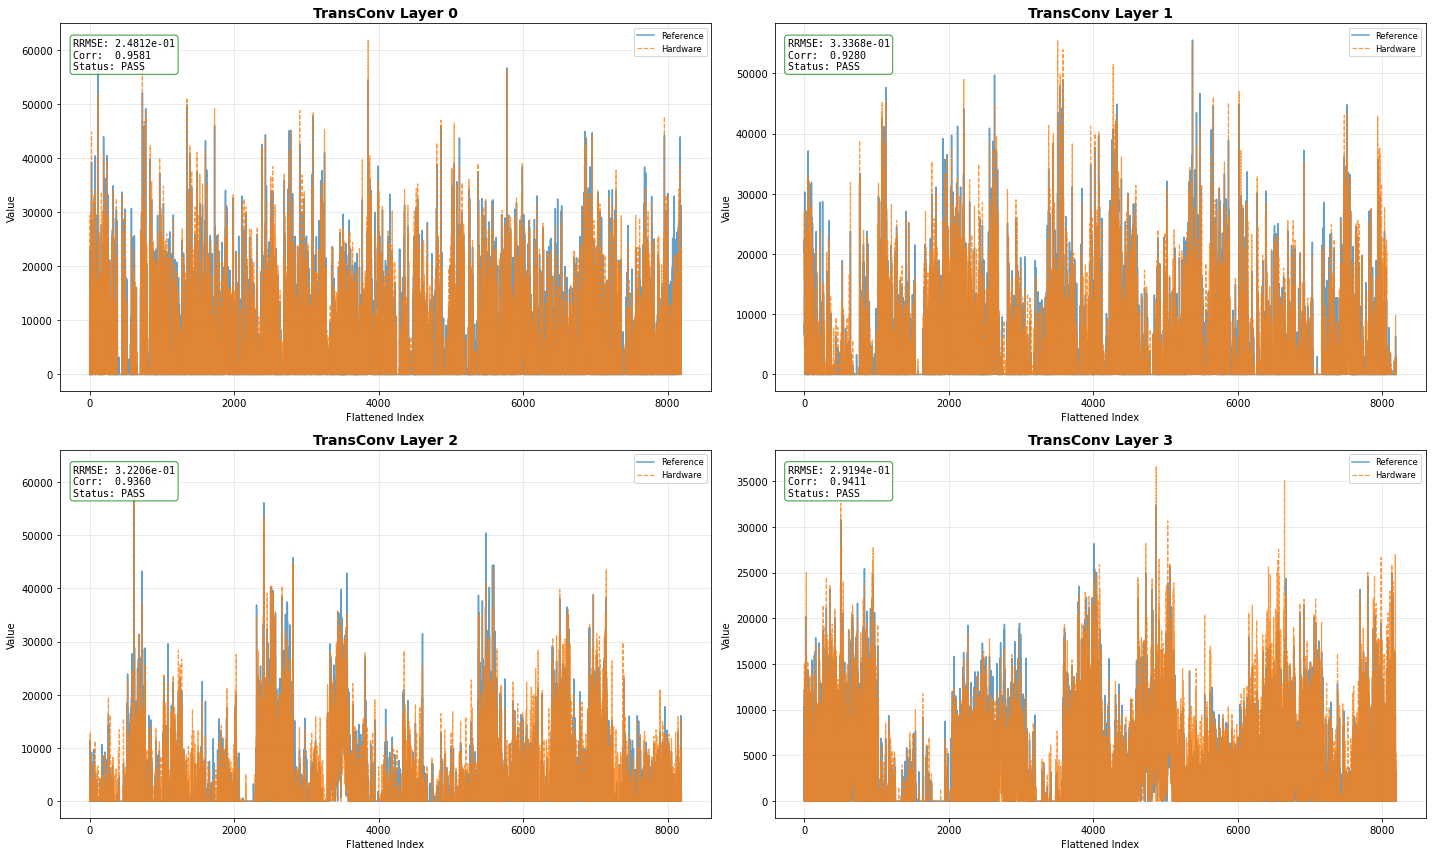

In [ ]:
hw_outputs = [hardware_out_l0, hardware_out_l1, hardware_out_l2, hardware_out_l3]
ref_outputs = [decoder_result0_2d, decoder_result1_2d, decoder_result2_2d, decoder_result3_2d]
metrics_all = [metrics_l0, metrics_l1, metrics_l2, metrics_l3]
layer_names = ["TransConv Layer 0", "TransConv Layer 1", "TransConv Layer 2", "TransConv Layer 3"]

plot_layers_grid(hw_outputs, ref_outputs, metrics_all, layer_names)